<a href="https://colab.research.google.com/github/Ben-Najafloo/BIS/blob/main/OLDpm4py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pm4py==1.5.2

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 696.1/696.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 47.9 MB/s eta 0:00:00
  Created wheel for intervaltree: filename=intervaltree-3.1.0-py2.py3-none-any.whl size=26098 sha256=3e7d641c5eb84498156276c7684b0493b97d91f29058bbfb55ace73b6c4eeebe
  Stored in directory: /root/.cache/pip/wheels/31/d7/d9/eec6891f78cac19a693bd40ecb8365d2f4613318c145ec9816
  Created wheel for stringdist: filename=StringDist-1.0.9-cp311-cp311-linux_x86_64.whl size=17371 sha256=6e01eaacb81ca48a3e81d4b13600730952c0326cc0158e87c72f602c28661a5e
  Stored in directory: /root/.cache/pip/wheels/fd/d0/9b/188e72fe6cc1ad1ae96a71835adb85cd58b0622a3440b4acdf
Successfully built intervaltree stringdist


In [ ]:
import pm4py

# Load XES file
from pm4py.objects.log.importer.xes import importer as xes_importer
# Load XES file with error handling
try:
    log = xes_importer.apply("/content/drive/MyDrive/Fine_Management.xes")
except FileNotFoundError:
    print("Error: File not found.")

# Number of cases
print(f"Number of cases: {len(log)}")

# Activities
from pm4py.statistics.attributes.log import get as attributes_get
activities = attributes_get.get_attribute_values(log, "concept:name")
print("Activities in log:")
for activity, count in activities.items():
    print(f"{activity}: {count}")


parsing log, completed traces ::   0%|          | 0/150370 [00:00<?, ?it/s]

Number of cases: 150370
Activities in log:
Create Fine: 150370
Send Fine: 103987
Insert Fine Notification: 79860
Add penalty: 79860
Send for Credit Collection: 59013
Payment: 77601
Insert Date Appeal to Prefecture: 4188
Send Appeal to Prefecture: 4141
Receive Result Appeal from Prefecture: 999
Notify Result Appeal to Offender: 896
Appeal to Judge: 555


# Analyzing variant sequence frequently  

In this section, the event log was analyzed to identify the most common behavioral patterns that occur throughout the process.

In [ ]:
import pandas as pd
from pm4py.statistics.variants.log import get as variants_get
from pm4py.objects.log.util import sorting

# Get all variants and their counts
variants = variants_get.get_variants(log)
variant_counts = [(variant.split(','), len(cases)) for variant, cases in variants.items()]

# Convert to DataFrame and calculate percentages
df_variants = pd.DataFrame({
    'Variant': [' -> '.join(variant) for variant, count in variant_counts],
    'Frequency': [count for variant, count in variant_counts]
})

# Add percentage column
total_cases = len(log)
df_variants['Percentage'] = (df_variants['Frequency'] / total_cases * 100).round(6)

# Sort and get top 10
df_variants = df_variants.sort_values('Frequency', ascending=False).reset_index(drop=True)
top_10_variants = df_variants.head(10)

# Display results
print(f"Total cases in log: {total_cases}")
print("\nTop 10 Variants:")
display(top_10_variants.style.format({'Percentage': '{:.6f}%'.format}))

Total cases in log: 150370

Top 10 Variants:


,Variant,Frequency,Percentage
0,Create Fine -> Send Fine -> Insert Fine Notification -> Add penalty -> Send for Credit Collection,56482,37.562014%
1,Create Fine -> Payment,46371,30.837933%
2,Create Fine -> Send Fine,20385,13.556560%
3,Create Fine -> Send Fine -> Insert Fine Notification -> Add penalty -> Payment,9520,6.331050%
4,Create Fine -> Send Fine -> Insert Fine Notification -> Add penalty -> Payment -> Payment,3736,2.484538%
5,Create Fine -> Send Fine -> Insert Fine Notification -> Payment -> Add penalty -> Payment,3301,2.195252%
6,Create Fine -> Send Fine -> Payment,3131,2.082197%
7,Create Fine -> Send Fine -> Insert Fine Notification -> Insert Date Appeal to Prefecture -> Add penalty -> Send Appeal to Prefecture,2497,1.660571%
8,Create Fine -> Send Fine -> Insert Fine Notification -> Add penalty -> Payment -> Send for Credit Collection,1515,1.007515%
9,Create Fine -> Send Fine -> Insert Fine Notification -> Payment -> Add penalty -> Send for Credit Collection,522,0.347144%


# Filtering and Processing Log file

In [ ]:
# Step 1: Filter traces with at least 3 events
filtered_log_by_length = [trace for trace in log if len(trace) >= 3]

# Step 2: Count activity occurrences
from collections import Counter
activity_counter = Counter(event["concept:name"] for trace in filtered_log_by_length for event in trace)

# Step 3: Keep only frequent activities (≥1000 occurrences)
frequent_activities = {activity for activity, count in activity_counter.items() if count >= 1000}

# Step 4: Filter events in each trace
filtered_log = []
for trace in filtered_log_by_length:
    new_trace = [event for event in trace if event["concept:name"] in frequent_activities]
    if new_trace:
        filtered_log.append(new_trace)

# Step 5: Print result
print(f"Filtered log - Number of cases: {len(filtered_log)}")

# Step 6: Show remaining activities
remaining_activities = Counter(event["concept:name"] for trace in filtered_log for event in trace)
print("Remaining activities:")
for activity, count in remaining_activities.items():
    print(f"{activity}: {count}")


Filtered log - Number of cases: 83614
Remaining activities:
Create Fine: 83614
Send Fine: 83602
Insert Fine Notification: 79860
Add penalty: 79860
Send for Credit Collection: 59013
Payment: 31230
Insert Date Appeal to Prefecture: 4188
Send Appeal to Prefecture: 4141


# Alpha Miner

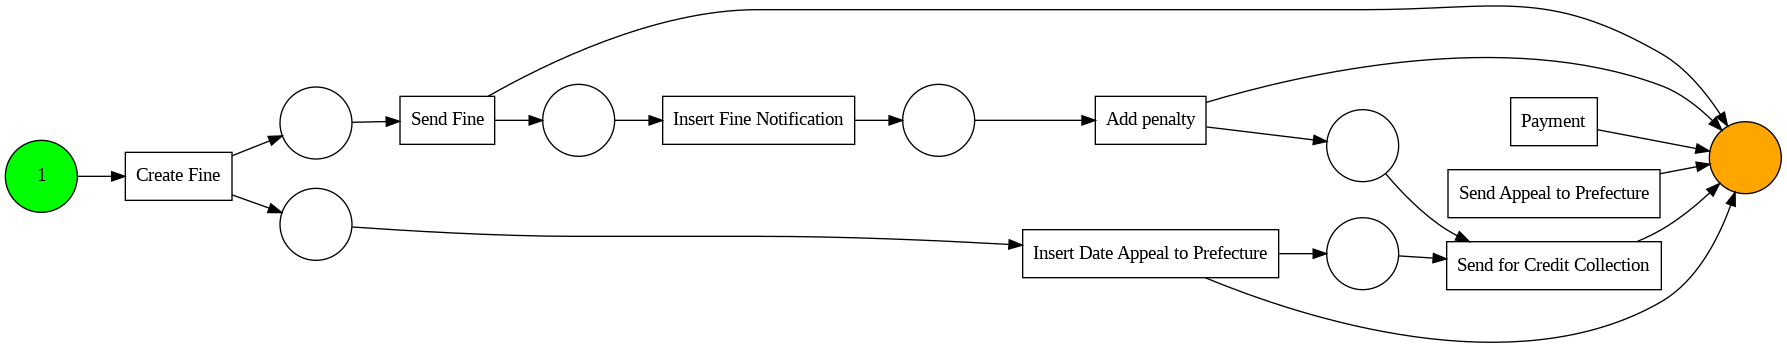

In [ ]:
# Apply Alpha Miner
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
from pm4py.visualization.petrinet import visualizer as pn_visualizer

net, initial_marking, final_marking = alpha_miner.apply(filtered_log)

# Visualize
gviz = pn_visualizer.apply(net, initial_marking, final_marking)
pn_visualizer.view(gviz)


# Inductive Miner

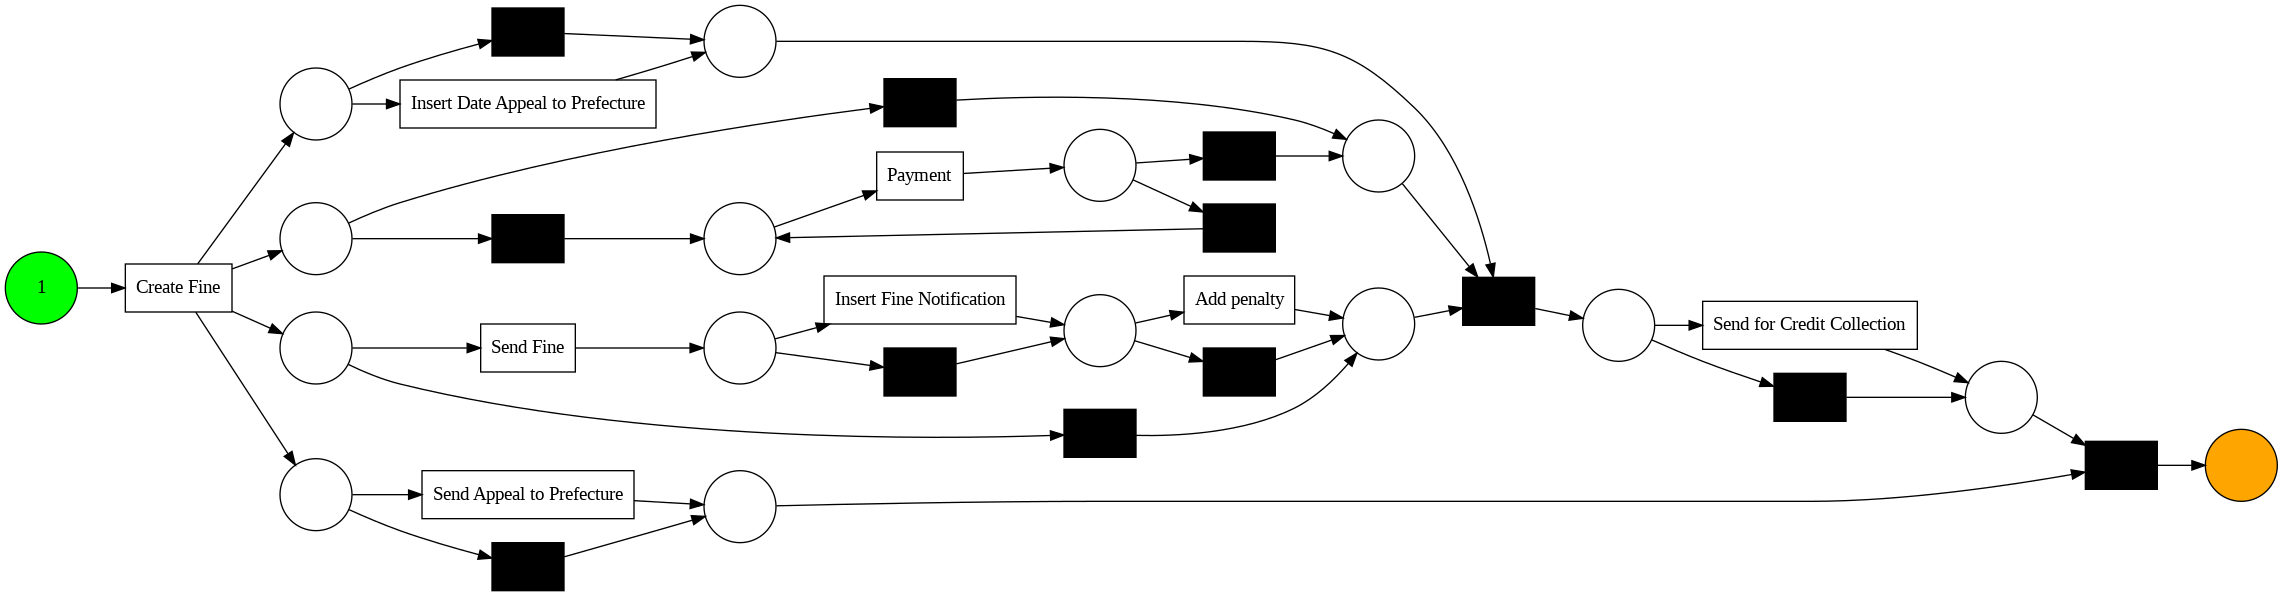

In [ ]:
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.visualization.petrinet import visualizer as pn_visualizer

net, initial_marking, final_marking = inductive_miner.apply(filtered_log)

# Visualize the Petri net
gviz = pn_visualizer.apply(net, initial_marking, final_marking)
pn_visualizer.view(gviz)


# Heuristic Miner

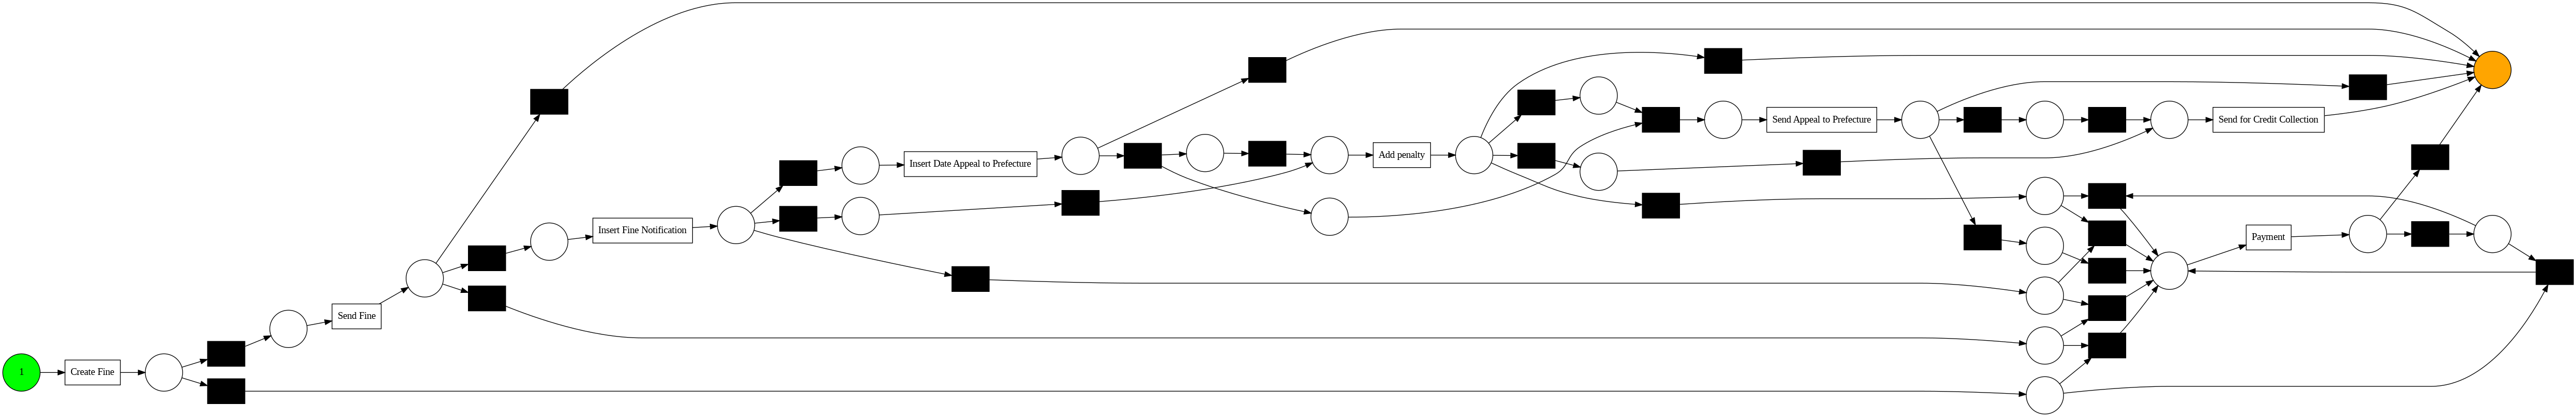

In [ ]:
from pm4py.algo.discovery.heuristics import algorithm as heuristic_miner
from pm4py.visualization.petrinet import visualizer as pn_visualizer

# Apply Heuristic Miner
net, initial_marking, final_marking = heuristic_miner.apply(filtered_log)

# Visualize the Petri net
gviz = pn_visualizer.apply(net, initial_marking, final_marking)
pn_visualizer.view(gviz)


Prcess Tree

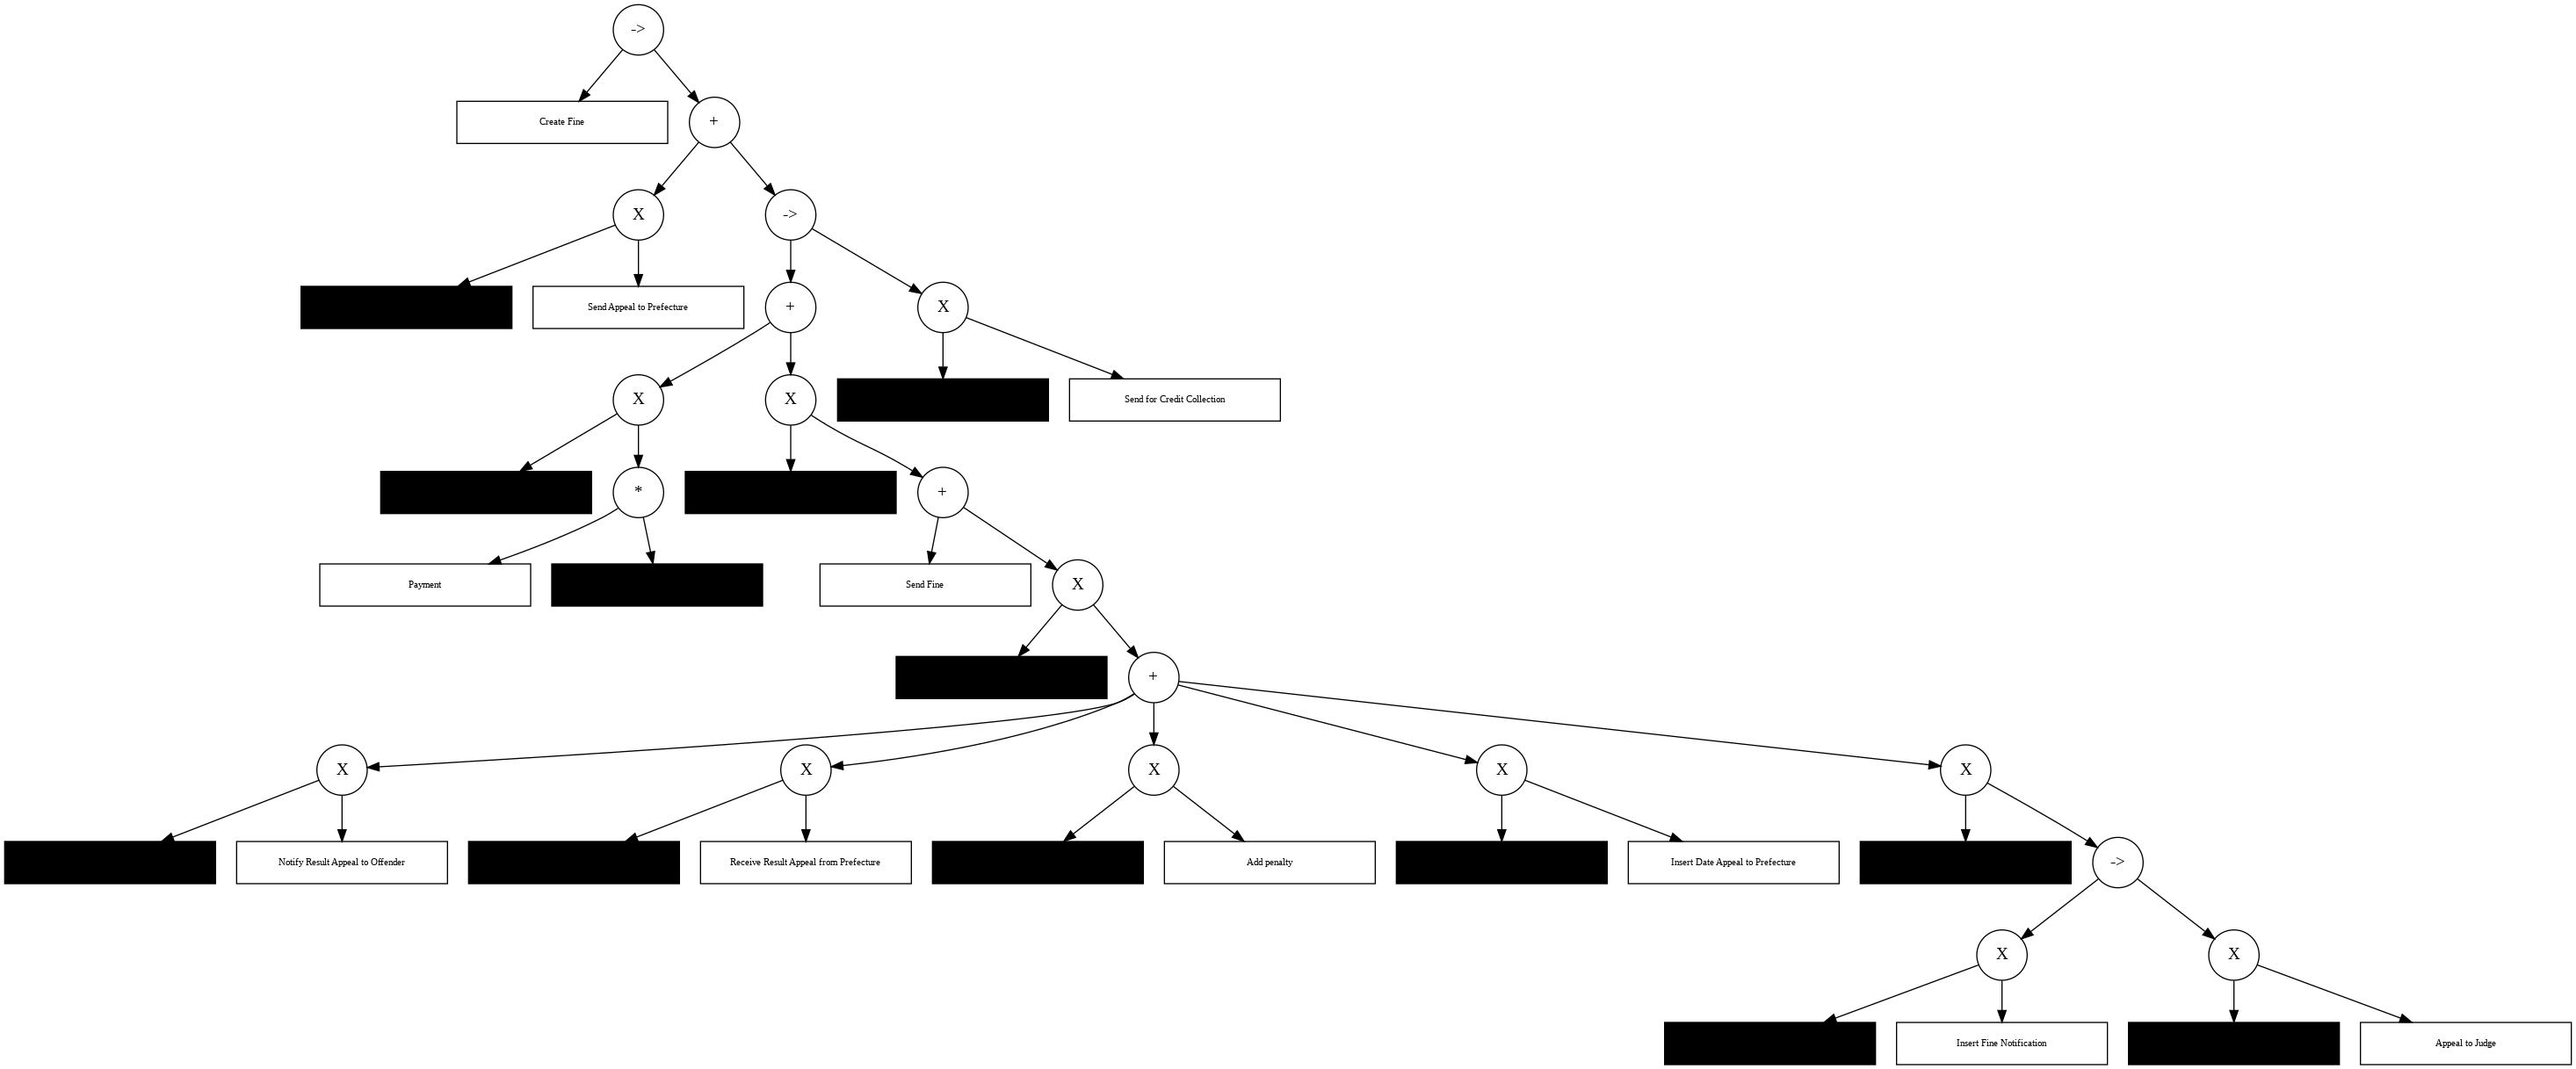

In [ ]:
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.visualization.process_tree import visualizer as pt_visualizer

process_tree = inductive_miner.apply_tree(log)
gviz = pt_visualizer.apply(process_tree)
pt_visualizer.view(gviz)

# Performance Comparison

In [ ]:
import time

# Measure time for Alpha Miner
start_time = time.time()
alpha_net, alpha_initial_marking, alpha_final_marking = alpha_miner.apply(filtered_log)
alpha_time = time.time() - start_time
print(f"Alpha Miner time: {alpha_time:.2f} seconds")

# Measure time for Inductive Miner
start_time = time.time()
inductive_net, inductive_initial_marking, inductive_final_marking = inductive_miner.apply(filtered_log)
inductive_time = time.time() - start_time
print(f"Inductive Miner time: {inductive_time:.2f} seconds")

# Measure time for Heuristic Miner
start_time = time.time()
heuristic_net, heuristic_initial_marking, heuristic_final_marking = heuristic_miner.apply(filtered_log)
heuristic_time = time.time() - start_time
print(f"Heuristic Miner time: {heuristic_time:.2f} seconds")


Alpha Miner time: 0.85 seconds
Inductive Miner time: 0.43 seconds
Heuristic Miner time: 2.10 seconds


In [ ]:
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay
from pm4py.objects.conversion.log import converter as log_converter

# Convert the event log to a format suitable for replay
log_for_replay = log_converter.apply(filtered_log, variant=log_converter.Variants.TO_EVENT_LOG)

# Alpha Miner fitness
replay_result_alpha = token_replay.apply(log_for_replay, alpha_net, alpha_initial_marking, alpha_final_marking)
fitness_alpha = sum([r['trace_fitness'] for r in replay_result_alpha]) / len(replay_result_alpha)
print(f"Alpha Miner Fitness: {fitness_alpha:.4f}")

# Inductive Miner fitness
replay_result_inductive = token_replay.apply(log_for_replay, inductive_net, inductive_initial_marking, inductive_final_marking)
fitness_inductive = sum([r['trace_fitness'] for r in replay_result_inductive]) / len(replay_result_inductive)
print(f"Inductive Miner Fitness: {fitness_inductive:.4f}")

# Heuristic Miner fitness
replay_result_heuristic = token_replay.apply(log_for_replay, heuristic_net, heuristic_initial_marking, heuristic_final_marking)
fitness_heuristic = sum([r['trace_fitness'] for r in replay_result_heuristic]) / len(replay_result_heuristic)
print(f"Heuristic Miner Fitness: {fitness_heuristic:.4f}")

Alpha Miner Fitness: 0.7633
Inductive Miner Fitness: 1.0000
Heuristic Miner Fitness: 0.9197


In [ ]:
print("Alpha Miner - Transitions:", len(alpha_net.transitions), "Places:", len(alpha_net.places))
print("Inductive Miner - Transitions:", len(inductive_net.transitions), "Places:", len(inductive_net.places))
print("Heuristic Miner - Transitions:", len(heuristic_net.transitions), "Places:", len(heuristic_net.places))

Alpha Miner - Transitions: 8 Places: 8
Inductive Miner - Transitions: 20 Places: 16
Heuristic Miner - Transitions: 38 Places: 28


# Data Segmentation

Activity filtering

In [ ]:
# Example: Filter traces with 'Payment' activity
filtered_log_payment = [trace for trace in filtered_log if any(event["concept:name"] == "Payment" for event in trace)]

print(f"Filtered log for 'Payment' - Number of cases: {len(filtered_log_payment)}")


Filtered log for 'Payment' - Number of cases: 69715


In [ ]:
# Apply Alpha Miner to the filtered data
alpha_net_filtered, alpha_initial_marking_filtered, alpha_final_marking_filtered = alpha_miner.apply(filtered_log_payment)

# Apply Inductive Miner to the filtered data
inductive_net_filtered, inductive_initial_marking_filtered, inductive_final_marking_filtered = inductive_miner.apply(filtered_log_payment)

# Apply Heuristic Miner to the filtered data
heuristic_net_filtered, heuristic_initial_marking_filtered, heuristic_final_marking_filtered = heuristic_miner.apply(filtered_log_payment)


# Process Discovery on Filtered Data

1. Alpha Miner

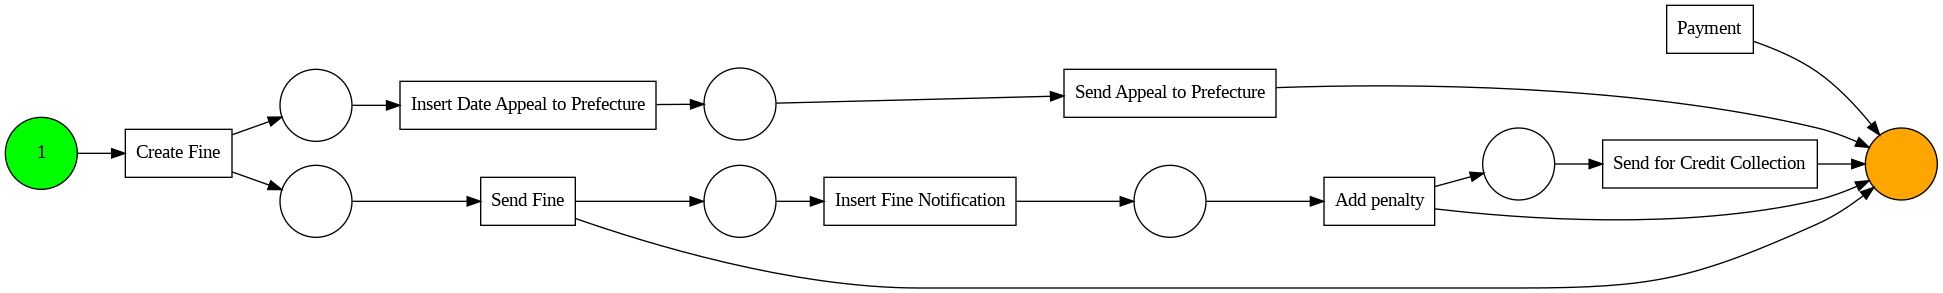

In [ ]:
# Apply Alpha Miner on filtered data
alpha_net_filtered, alpha_initial_marking_filtered, alpha_final_marking_filtered = alpha_miner.apply(filtered_log_payment)

# Visualize the Petri net
alpha_gviz = pn_visualizer.apply(alpha_net_filtered, alpha_initial_marking_filtered, alpha_final_marking_filtered)
pn_visualizer.view(alpha_gviz)


2. Inductive Miner

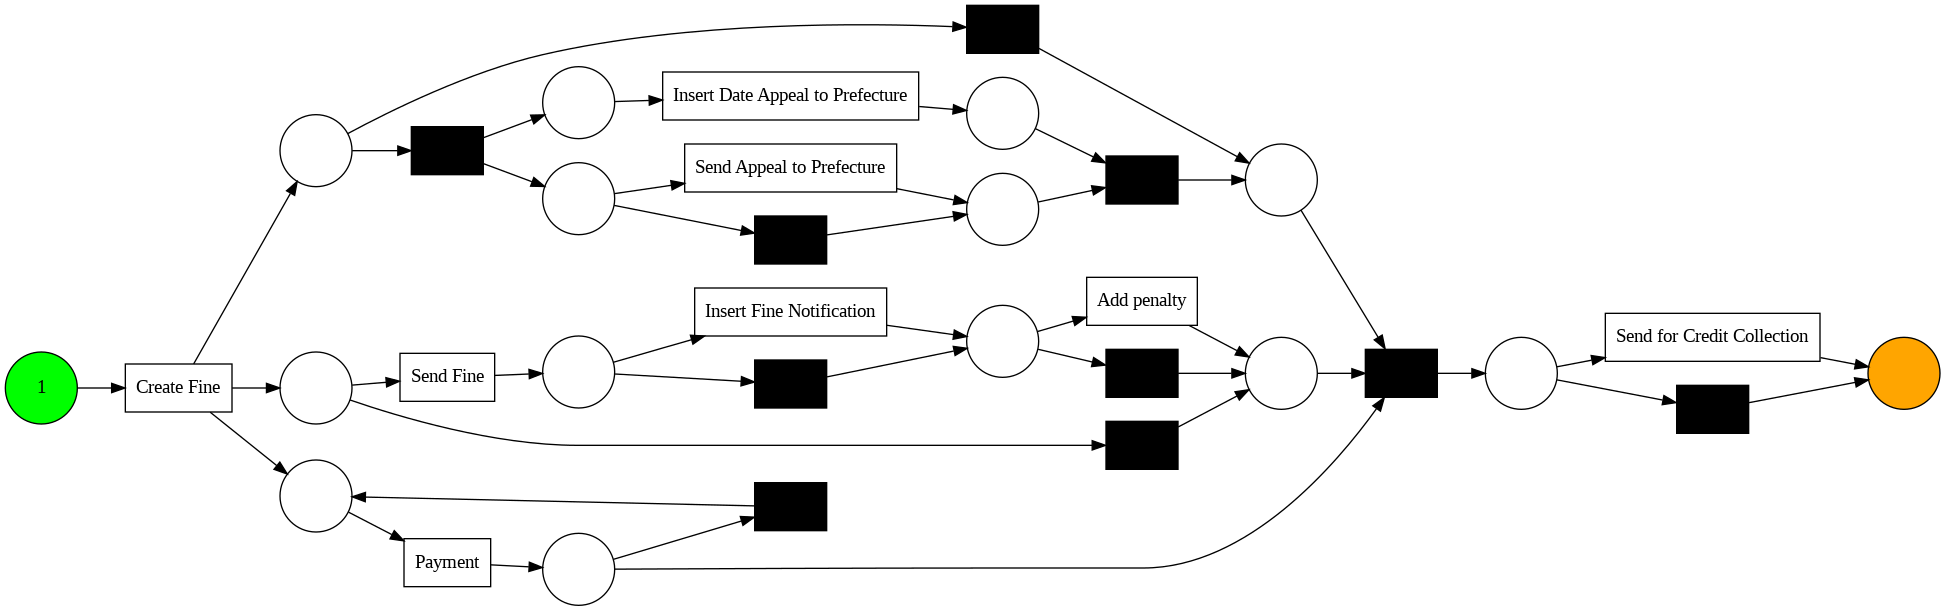

In [ ]:
# Apply Inductive Miner on filtered data
inductive_net_filtered, inductive_initial_marking_filtered, inductive_final_marking_filtered = inductive_miner.apply(filtered_log_payment)

# Visualize the Petri net
inductive_gviz = pn_visualizer.apply(inductive_net_filtered, inductive_initial_marking_filtered, inductive_final_marking_filtered)
pn_visualizer.view(inductive_gviz)


3. Heuristic Miner

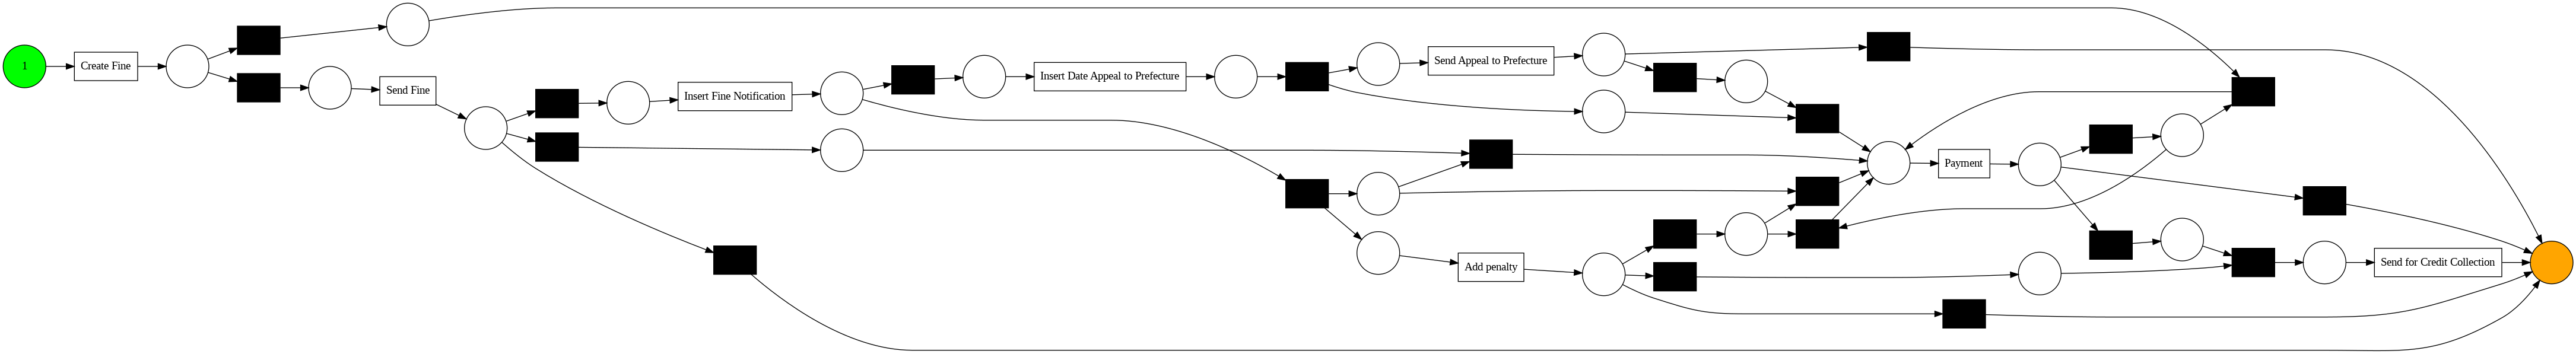

In [ ]:
# Apply Heuristic Miner on filtered data
heuristic_net_filtered, heuristic_initial_marking_filtered, heuristic_final_marking_filtered = heuristic_miner.apply(filtered_log_payment)

# Visualize the Petri net
heuristic_gviz = pn_visualizer.apply(heuristic_net_filtered, heuristic_initial_marking_filtered, heuristic_final_marking_filtered)
pn_visualizer.view(heuristic_gviz)
